In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (8,5)

In [5]:
master= pd.read_csv("../data/processed/master.csv")

In [6]:
master["future_return"].describe()

count    4667.000000
mean       -0.007323
std         0.072014
min        -0.239105
25%        -0.056594
50%        -0.008838
75%         0.040610
max         0.273827
Name: future_return, dtype: float64

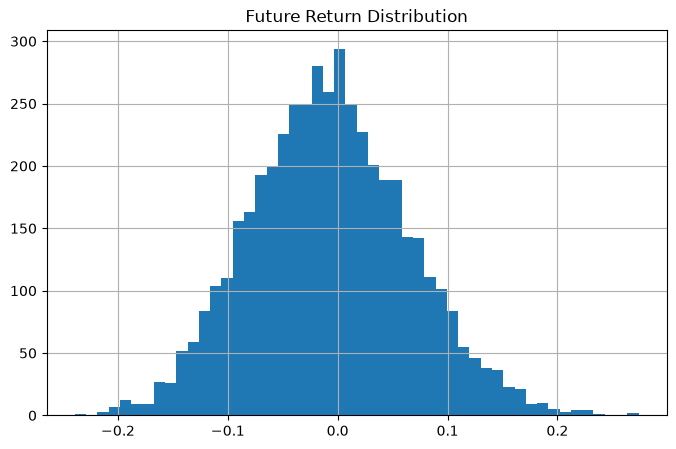

In [7]:
master["future_return"].hist(bins=50)
plt.title("Future Return Distribution")
plt.show()

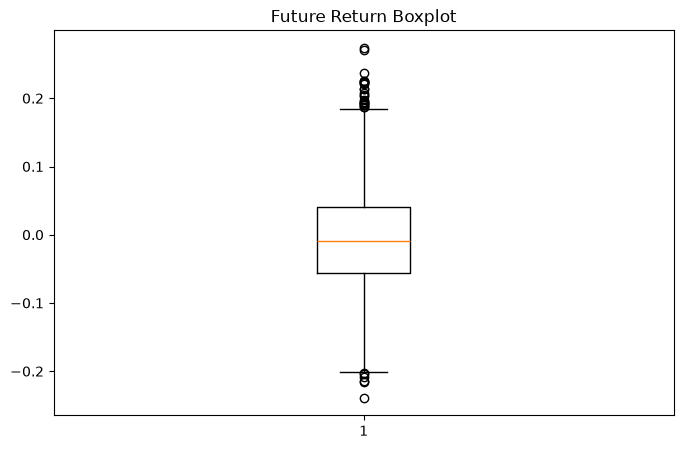

In [8]:
plt.boxplot(master["future_return"].dropna())
plt.title("Future Return Boxplot")
plt.show()

# Observations
The future return graph is almost bell shaped with centre near zero.
Mean is around 0.73%.
Most companies generated returns between roughly -10% and +10%.
Skewness is almost negligible.
A small number of companies experienced exceptionally high or low returns.


In [9]:
[c for c in master.columns if "return on equity" in c.lower()]

['Return on equity', 'Return on equity preceding year']

In [10]:
master["Return on equity"].describe()

count     4233.000000
mean        11.650142
std        215.482507
min      -3559.090000
25%          1.410000
50%          8.200000
75%         17.470000
max      13100.000000
Name: Return on equity, dtype: float64

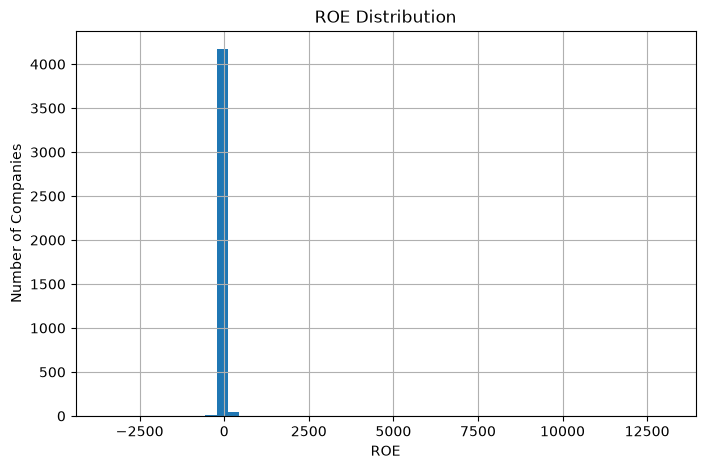

In [11]:
master["Return on equity"].hist(bins=50)

plt.title("ROE Distribution")
plt.xlabel("ROE")
plt.ylabel("Number of Companies")

plt.show()

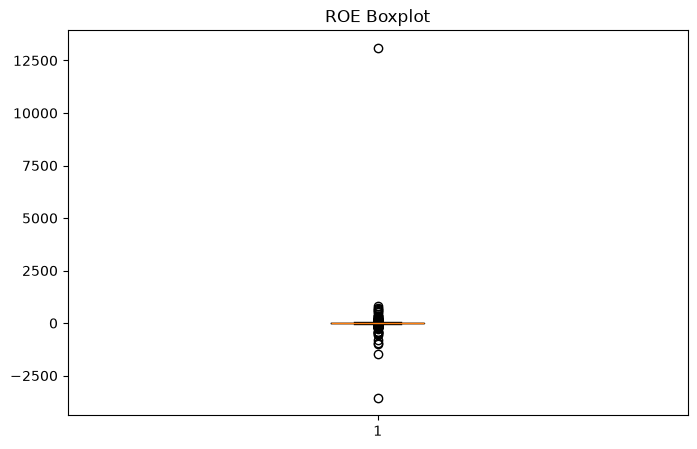

In [12]:
plt.boxplot(master["Return on equity"].dropna())

plt.title("ROE Boxplot")

plt.show()

In [13]:
master["Return on equity"].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

0.01   -109.400
0.05    -17.908
0.25      1.410
0.50      8.200
0.75     17.470
0.95     44.340
0.99    119.702
Name: Return on equity, dtype: float64

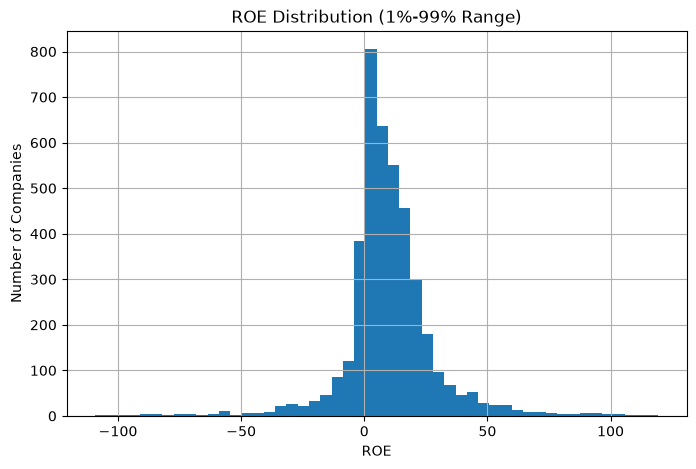

In [14]:
roe_filtered = master[
    master["Return on equity"].between(
        master["Return on equity"].quantile(0.01),
        master["Return on equity"].quantile(0.99)
    )
]

roe_filtered["Return on equity"].hist(bins=50)

plt.title("ROE Distribution (1%-99% Range)")
plt.xlabel("ROE")
plt.ylabel("Number of Companies")

plt.show()

The ROE distribution contains extreme outliers, with a maximum value of 13,100%. Quantile analysis revealed that 99% of companies have ROE below 120%, indicating that a small number of observations distort the overall distribution. Subsequent visualizations were generated using the 1st–99th percentile range for better interpretability.

The ROE distribution is centered around positive values, indicating that most companies are profitable. The distribution exhibits mild right skewness due to a subset of firms with exceptionally high returns on equity. Extreme outliers exist but are limited to a very small fraction of observations.

In [15]:
master["Debt to equity"].describe()

count    4310.000000
mean        1.201624
std         8.245210
min         0.000000
25%         0.020000
50%         0.220000
75%         0.770000
max       371.240000
Name: Debt to equity, dtype: float64

In [16]:
master["Debt to equity"].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

0.01     0.0000
0.05     0.0000
0.25     0.0200
0.50     0.2200
0.75     0.7700
0.95     3.4565
0.99    13.9677
Name: Debt to equity, dtype: float64

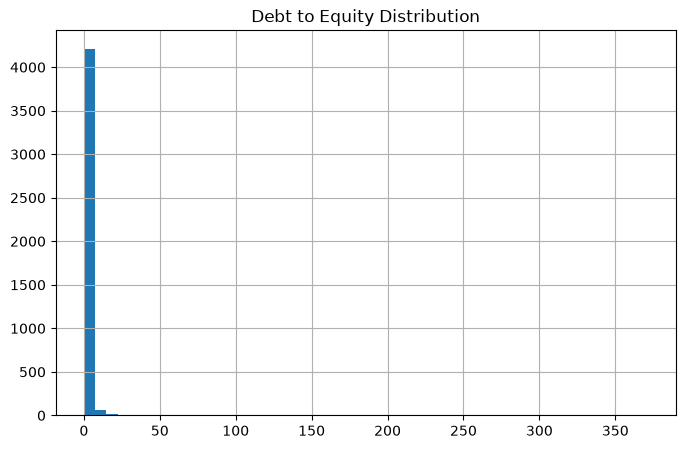

In [17]:
master["Debt to equity"].hist(bins=50)
plt.title("Debt to Equity Distribution")
plt.show()

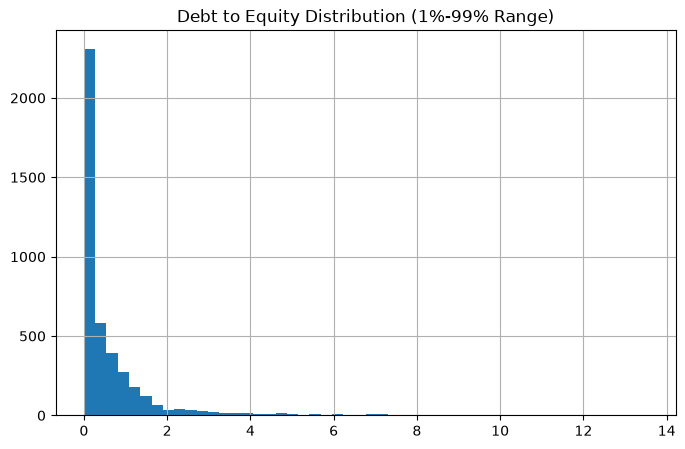

In [20]:
dte_filtered = master[
    master["Debt to equity"].between(
        master["Debt to equity"].quantile(0.01),
        master["Debt to equity"].quantile(0.99)
    )
]
dte_filtered["Debt to equity"].hist(bins=50)
plt.title("Debt to Equity Distribution (1%-99% Range)")         
plt.show()

The Debt to Equity ratio exhibits strong positive skewness. Most firms maintain relatively low leverage, with the majority of observations concentrated below 1. A small subset of firms carries substantially higher debt burdens, producing a long right tail.

In [21]:
master["Price to Earning"].describe()

count     3627.000000
mean        94.453959
std        374.364771
min          0.000000
25%         19.175000
50%         33.720000
75%         65.880000
max      12317.900000
Name: Price to Earning, dtype: float64

In [22]:
master["Price to Earning"].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

0.01       2.7338
0.05       8.0660
0.25      19.1750
0.50      33.7200
0.75      65.8800
0.95     287.5590
0.99    1158.3048
Name: Price to Earning, dtype: float64

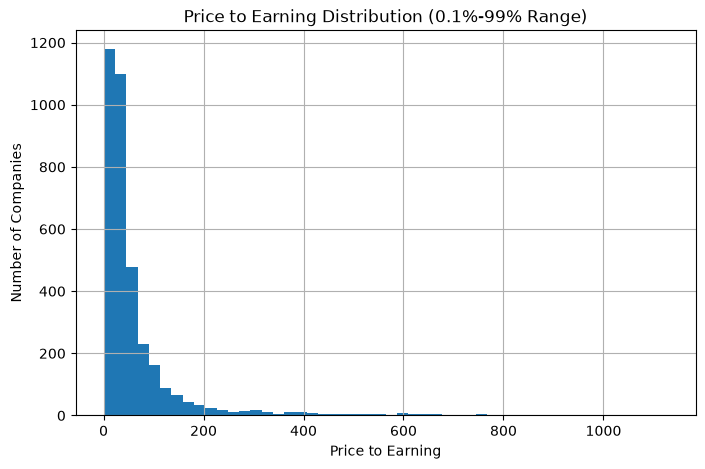

In [23]:
pe_filtered = master[
    master["Price to Earning"].between(
        master["Price to Earning"].quantile(0.001),
        master["Price to Earning"].quantile(0.99)       
    )
]
pe_filtered["Price to Earning"].hist(bins=50)
plt.title("Price to Earning Distribution (0.1%-99% Range)")
plt.xlabel("Price to Earning")
plt.ylabel("Number of Companies")
plt.show()

The Price-to-Earnings ratio exhibits strong positive skewness. While the median P/E is approximately 34, a small number of firms display extremely high valuations, producing a long right tail. This suggests that investor expectations and company earnings vary substantially across firms.

In [29]:
master["Market Capitalization_bal"].describe()

count    4.668000e+03
mean     9.528972e+03
std      5.921956e+04
min      5.000000e-02
25%      3.669250e+01
50%      1.958900e+02
75%      1.721570e+03
max      2.114993e+06
Name: Market Capitalization_bal, dtype: float64

In [30]:
master["Market Capitalization_bal"].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

0.01         2.5467
0.05         6.1070
0.25        36.6925
0.50       195.8900
0.75      1721.5700
0.95     33840.3145
0.99    184724.4179
Name: Market Capitalization_bal, dtype: float64

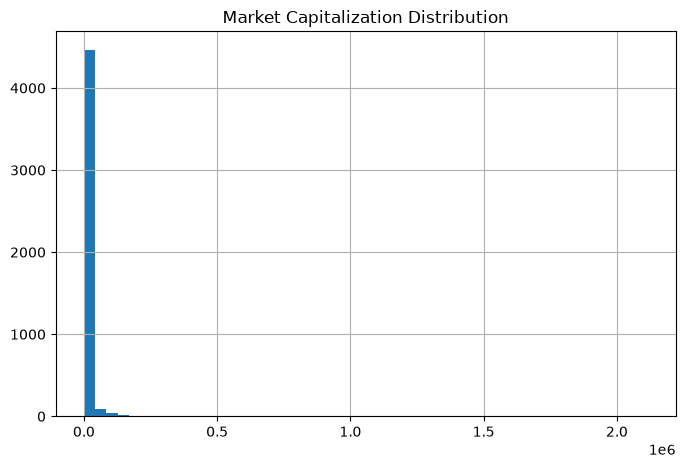

In [31]:
master["Market Capitalization_bal"].hist(bins=50)

plt.title("Market Capitalization Distribution")
plt.show()

In [34]:
mcap_filtered = master[
    master["Market Capitalization_bal"].between(
        master["Market Capitalization_bal"].quantile(0.05),
        master["Market Capitalization_bal"].quantile(0.95)
    )
]

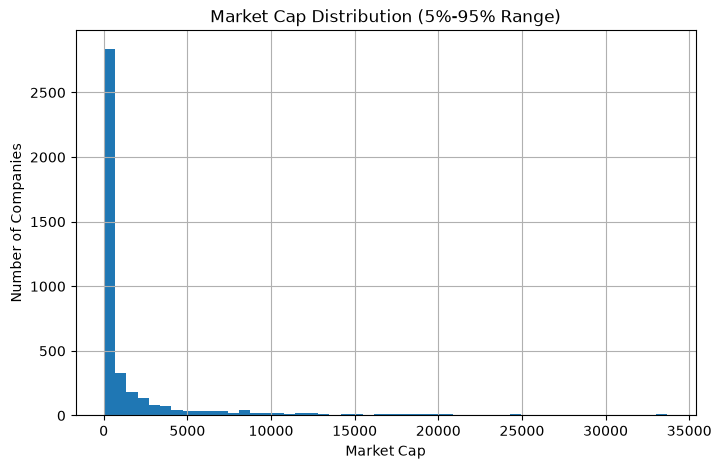

In [35]:
mcap_filtered["Market Capitalization_bal"].hist(bins=50)

plt.title("Market Cap Distribution (5%-95% Range)")
plt.xlabel("Market Cap")
plt.ylabel("Number of Companies")

plt.show()

Market Capitalization exhibits extreme positive skewness, with a large concentration of firms having relatively small market values and a small number of firms accounting for very large market capitalizations. This pattern is consistent with real-world equity markets where a limited number of firms dominate total market value.

In [42]:
master["Promoter holding"].describe()

count    4653.000000
mean       53.106628
std        21.101361
min         0.000000
25%        42.330000
50%        58.320000
75%        70.420000
max       100.000000
Name: Promoter holding, dtype: float64

In [43]:
master["Promoter holding"].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

0.01     0.0000
0.05     3.9640
0.25    42.3300
0.50    58.3200
0.75    70.4200
0.95    74.9600
0.99    83.2148
Name: Promoter holding, dtype: float64

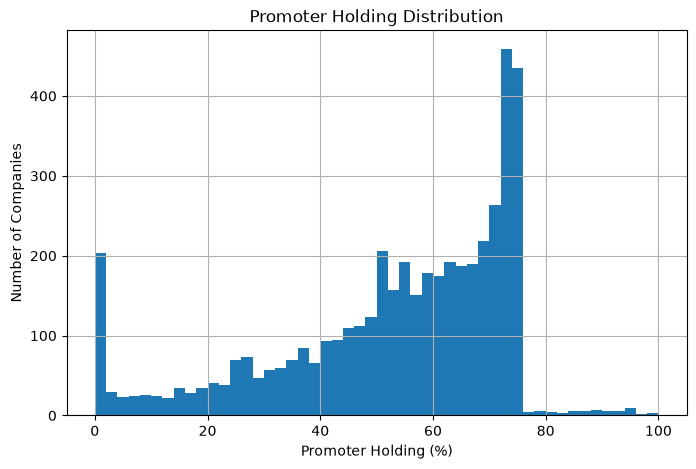

In [44]:
master["Promoter holding"].hist(bins=50)
plt.title("Promoter Holding Distribution")
plt.xlabel("Promoter Holding (%)")
plt.ylabel("Number of Companies")
plt.show()
    

Promoter holding is generally high across the dataset, with a median ownership of 58.3%. The distribution is concentrated between 50% and 75%, indicating that many firms remain promoter controlled. A small subset of companies exhibits near-zero promoter ownership, reflecting widely held ownership structures.

In [46]:
master["Industry_bal"].value_counts().head(20)

Industry_bal
Finance & Investments                             560
Trading                                           532
Miscellaneous                                     410
Construction                                      323
Computers - Software - Medium / Small             241
Chemicals                                         139
Engineering                                       125
Textiles - Products                               118
Auto Ancillaries                                  110
Steel - Medium / Small                            104
Food - Processing - Indian                        100
Entertainment / Electronic Media Software          91
Pharmaceuticals - Indian - Bulk Drugs & Formln     88
Plastics Products                                  87
Electric Equipment                                 84
Packaging                                          80
Hotels                                             72
Textiles - Cotton/Blended                          70
Mining / Minera

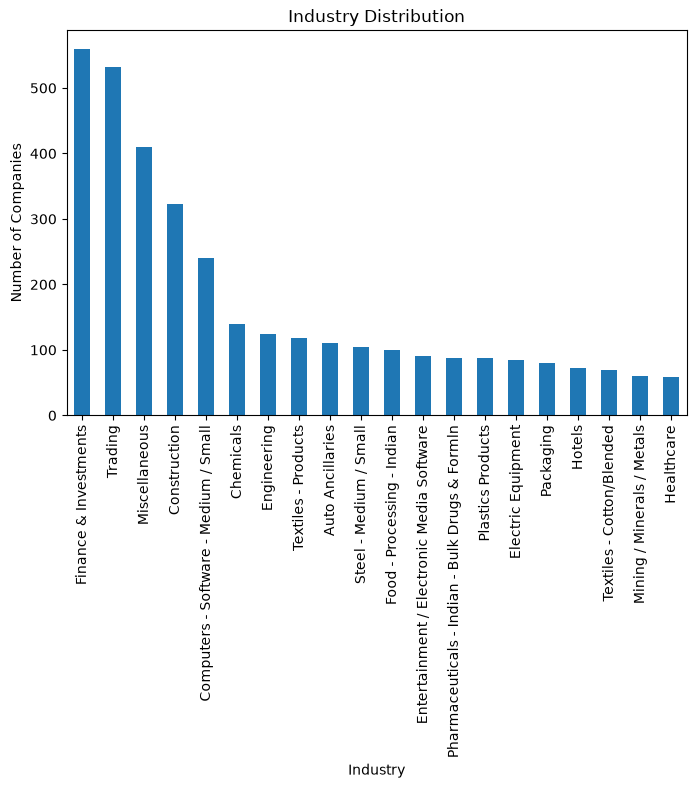

In [49]:
master["Industry_bal"].value_counts().head(20).plot(kind='bar')
plt.title("Industry Distribution")
plt.xlabel("Industry")
plt.ylabel("Number of Companies")
plt.show()

The dataset is industry diverse but not uniformly distributed. Finance & Investments and Trading constitute the largest categories, while Healthcare and Mining represent smaller portions. The imbalance suggests that industry specific effects may influence financial ratios and stock return behavior.

In [50]:
master[["Return on equity", "future_return"]].corr()

,Return on equity,future_return
Return on equity,1.000000,0.066968
future_return,0.066968,1.000000


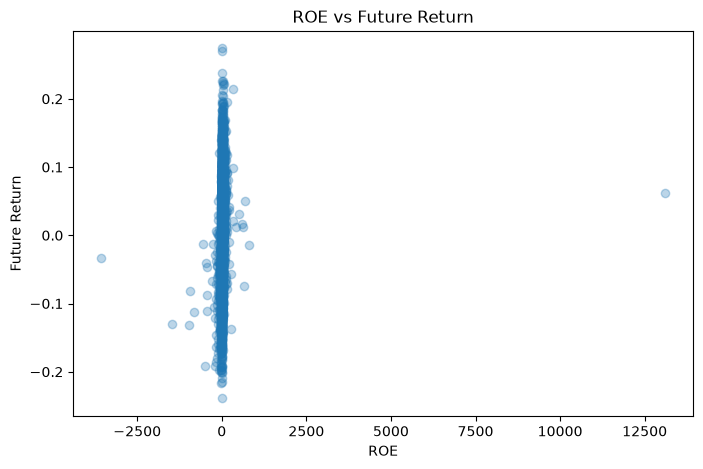

In [53]:
plt.figure(figsize=(8,5))

plt.scatter(
    master["Return on equity"],
    master["future_return"], alpha=0.3
)

plt.xlabel("ROE")
plt.ylabel("Future Return")
plt.title("ROE vs Future Return")

plt.show()

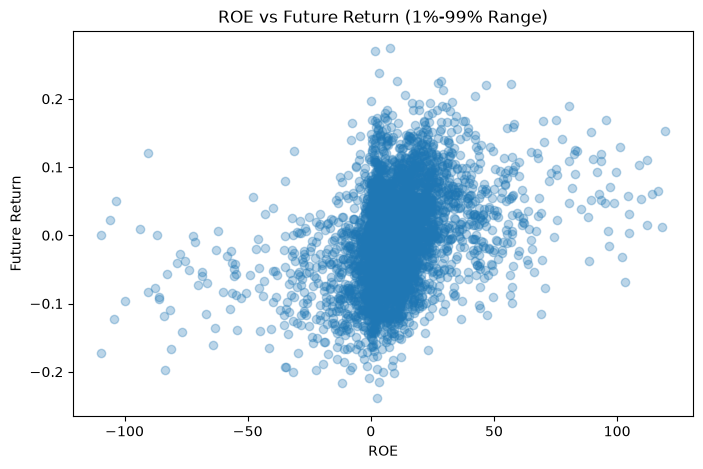

In [54]:
roe_filtered = master[
    master["Return on equity"].between(
        master["Return on equity"].quantile(0.01),
        master["Return on equity"].quantile(0.99)
    )
]

plt.figure(figsize=(8,5))

plt.scatter(
    roe_filtered["Return on equity"],
    roe_filtered["future_return"],
    alpha=0.3
)

plt.xlabel("ROE")
plt.ylabel("Future Return")
plt.title("ROE vs Future Return (1%-99% Range)")

plt.show()

ROE exhibits a weak positive relationship with future returns (correlation = 0.067). While firms with higher profitability tend to generate slightly better subsequent performance, ROE alone explains only a small fraction of return variation.

In [55]:
master[["Debt to equity","future_return"]].corr()

,Debt to equity,future_return
Debt to equity,1.000000,-0.079659
future_return,-0.079659,1.000000


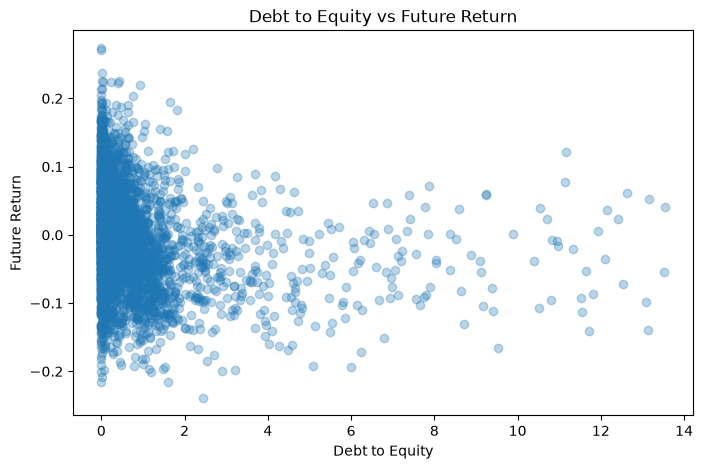

In [56]:
dte_filtered = master[
    master["Debt to equity"].between(
        master["Debt to equity"].quantile(0.01),
        master["Debt to equity"].quantile(0.99)
    )
]

plt.figure(figsize=(8,5))

plt.scatter(
    dte_filtered["Debt to equity"],
    dte_filtered["future_return"],
    alpha=0.3
)

plt.xlabel("Debt to Equity")
plt.ylabel("Future Return")
plt.title("Debt to Equity vs Future Return")

plt.show()

In [57]:
master[["Price to Earning","future_return"]].corr()

,Price to Earning,future_return
Price to Earning,1.000000,-0.047168
future_return,-0.047168,1.000000


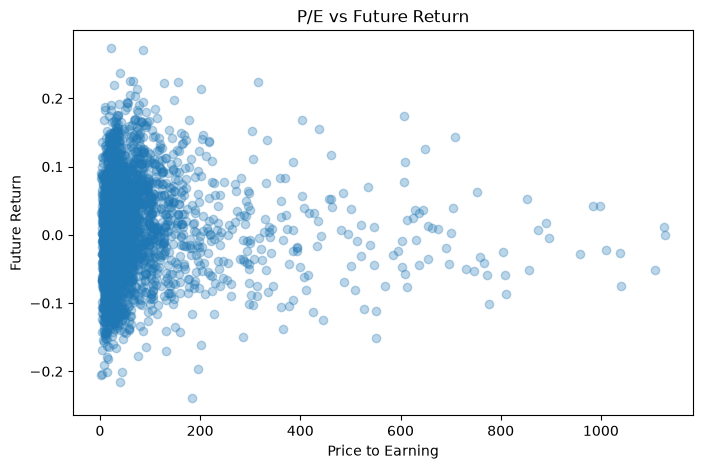

In [58]:
pe_filtered = master[
    master["Price to Earning"].between(
        master["Price to Earning"].quantile(0.01),
        master["Price to Earning"].quantile(0.99)
    )
]

plt.figure(figsize=(8,5))

plt.scatter(
    pe_filtered["Price to Earning"],
    pe_filtered["future_return"],
    alpha=0.3
)

plt.xlabel("Price to Earning")
plt.ylabel("Future Return")
plt.title("P/E vs Future Return")

plt.show()

In [59]:
master[["Market Capitalization_bal","future_return"]].corr()

,Market Capitalization_bal,future_return
Market Capitalization_bal,1.000000,0.086122
future_return,0.086122,1.000000


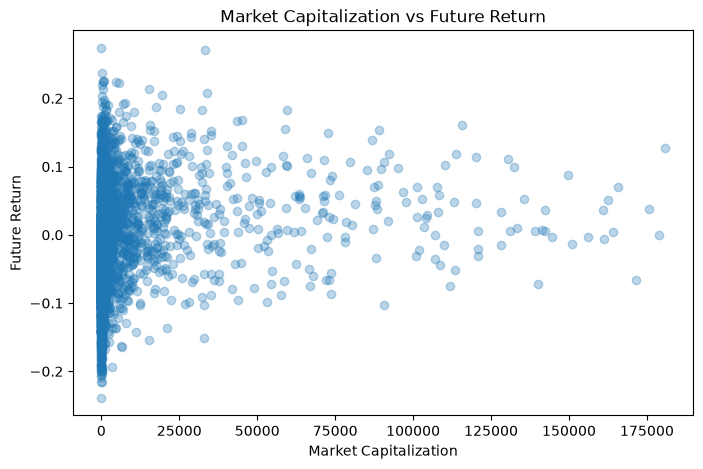

In [60]:
market_filtered= master[
    master["Market Capitalization_bal"].between(
        master["Market Capitalization_bal"].quantile(0.01),
        master["Market Capitalization_bal"].quantile(0.99)
    )
]

plt.figure(figsize=(8,5))

plt.scatter(
    market_filtered["Market Capitalization_bal"],
    market_filtered["future_return"],
    alpha=0.3
)

plt.xlabel("Market Capitalization")
plt.ylabel("Future Return")
plt.title("Market Capitalization vs Future Return")

plt.show()

In [61]:
master[["Promoter holding","future_return"]].corr()

,Promoter holding,future_return
Promoter holding,1.000000,0.117646
future_return,0.117646,1.000000


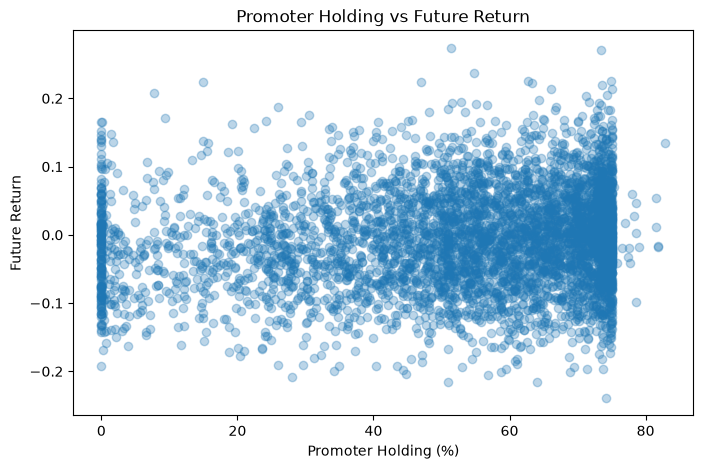

In [62]:
promoter_filtered = master[
    master["Promoter holding"].between(
        master["Promoter holding"].quantile(0.01),
        master["Promoter holding"].quantile(0.99)
    )
]       
plt.figure(figsize=(8,5))
plt.scatter(
    promoter_filtered["Promoter holding"],
    promoter_filtered["future_return"],
    alpha=0.3
)
plt.xlabel("Promoter Holding (%)")
plt.ylabel("Future Return")
plt.title("Promoter Holding vs Future Return")
plt.show()


In [63]:
master.groupby("Industry_bal")["future_return"]\
      .mean()\
      .sort_values(ascending=False)\
      .head(15)

Industry_bal
Pharmaceuticals - Multinational            0.102879
Abrasives And Grinding Wheels              0.097525
Pumps                                      0.079296
Diversified - Mega                         0.071631
Computers - Software - Large               0.069531
Automobiles - Passenger Cars               0.064340
Personal Care - Multinational              0.062879
Automobiles - Scooters And 3 - Wheelers    0.060148
Transmisson Line Towers / Equipment        0.057404
Diversified - Large                        0.053098
Compressors / Drilling Equipment           0.049480
Engines                                    0.048828
Automobiles - LCVs / HCVs                  0.047391
Travel Agencies                            0.045379
Automobiles - Motorcycles / Mopeds         0.043377
Name: future_return, dtype: float64

In [65]:
master.groupby("Industry_bal")["future_return"]\
      .mean()\
      .sort_values()\
      .head(15)

Industry_bal
Textiles - Composite                -0.072345
Textiles - Cotton/Blended           -0.047475
Textiles - Processing               -0.047260
Aquaculture                         -0.046957
Banks - Private Sector              -0.043117
Paper                               -0.042204
Finance - Housing                   -0.041088
Fertilizers                         -0.040921
Steel - Pig Iron                    -0.040880
Steel - Sponge Iron                 -0.036443
Tea                                 -0.033771
Glass & Glass Products              -0.029396
Textiles - Manmade                  -0.029162
Packaging                           -0.028330
Textiles - Jute - Yarn / Products   -0.027221
Name: future_return, dtype: float64

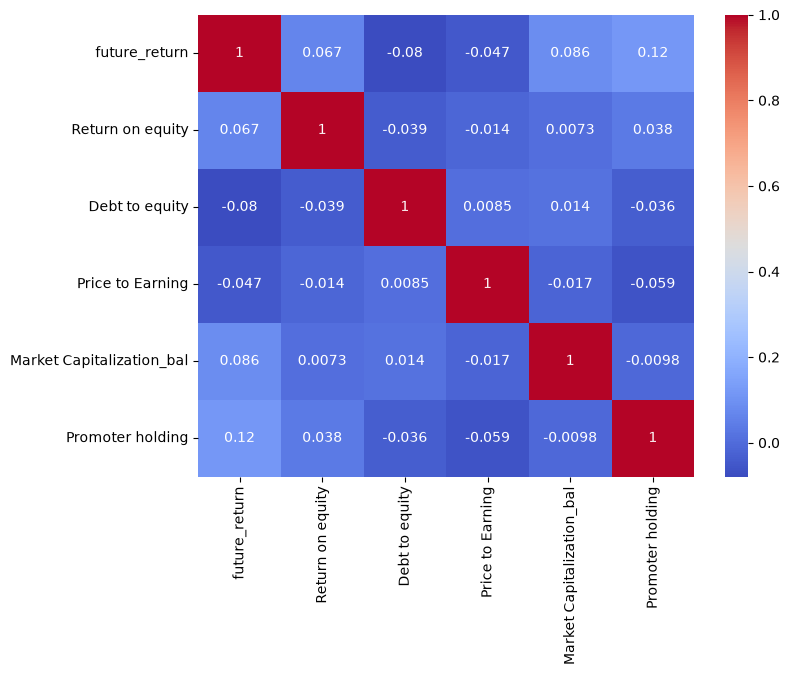

In [67]:
import seaborn as sns

cols = [
    "future_return",
    "Return on equity",
    "Debt to equity",
    "Price to Earning",
    "Market Capitalization_bal",
    "Promoter holding"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    master[cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [68]:
corr_with_target = (
    master.corr(numeric_only=True)["future_return"]
    .sort_values(ascending=False)
)

corr_with_target.head(20)
corr_with_target.tail(20)

Preference capital                   -0.004007
Book value of unquoted investments   -0.004092
Debt preceding year                  -0.004522
Debt 3Years back                     -0.005229
Debt                                 -0.005867
Cash Conversion Cycle                -0.006364
Debtor days                          -0.007111
Days Receivable Outstanding          -0.007111
Revaluation reserve                  -0.007380
Secured loan                         -0.011657
Days Payable Outstanding             -0.014079
Days Inventory Outstanding           -0.016893
Face value                           -0.024651
Price to Earning                     -0.047168
Debt to equity                       -0.079659
Pledged percentage                   -0.087434
BSE Code_bal                         -0.121691
BSE Code_rat                         -0.121691
Public holding                       -0.204374
Credit rating                              NaN
Name: future_return, dtype: float64

In [69]:
corr_with_target.head(20)

future_return                               1.000000
DII holding                                 0.163525
FII holding                                 0.153127
Piotroski score                             0.139197
t_1_price                                   0.138700
G Factor                                    0.136376
Unpledged promoter holding                  0.136269
Current Price_rat                           0.126847
Current Price_bal                           0.126693
Return on equity preceding year             0.122374
Promoter holding                            0.117646
Industry PE                                 0.087827
Market Capitalization_bal                   0.086122
Market Capitalization_rat                   0.086062
Change in FII holding                       0.069940
Return on equity                            0.066968
Trade receivables                           0.058002
Return on assets preceding year             0.051930
Number of Shareholders preceding quarter    0.

In [70]:
corr_with_target[
    corr_with_target.abs().sort_values(ascending=False).index
].head(20)

future_return                      1.000000
Public holding                    -0.204374
DII holding                        0.163525
FII holding                        0.153127
Piotroski score                    0.139197
t_1_price                          0.138700
G Factor                           0.136376
Unpledged promoter holding         0.136269
Current Price_rat                  0.126847
Current Price_bal                  0.126693
Return on equity preceding year    0.122374
BSE Code_bal                      -0.121691
BSE Code_rat                      -0.121691
Promoter holding                   0.117646
Industry PE                        0.087827
Pledged percentage                -0.087434
Market Capitalization_bal          0.086122
Market Capitalization_rat          0.086062
Debt to equity                    -0.079659
Change in FII holding              0.069940
Name: future_return, dtype: float64

In [71]:
master["Piotroski score"].describe()

count    4668.000000
mean        5.193659
std         1.931932
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max         9.000000
Name: Piotroski score, dtype: float64

In [72]:
master.groupby("Piotroski score")["future_return"].mean()

Piotroski score
0.0    0.059147
1.0   -0.012174
2.0   -0.031239
3.0   -0.027285
4.0   -0.012671
5.0   -0.010548
6.0   -0.000526
7.0    0.003338
8.0    0.009375
9.0    0.010199
Name: future_return, dtype: float64

<Axes: xlabel='Piotroski score'>

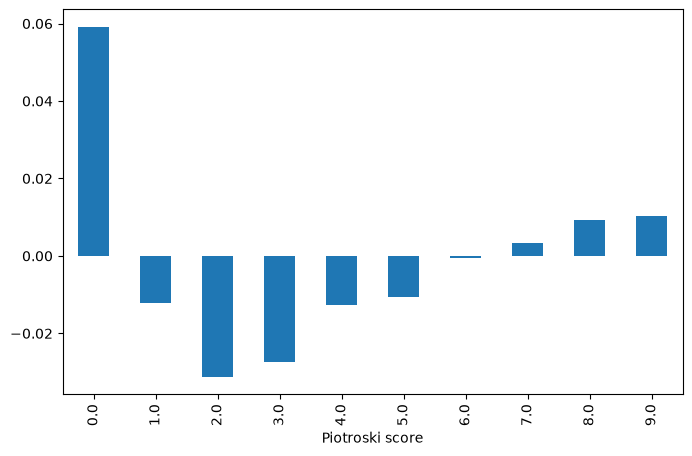

In [76]:
master.groupby("Piotroski score")["future_return"]\
      .mean()\
      .plot(kind="bar")

In [75]:
(master["DII holding"] == 0).mean()

np.float64(0.5062125107112254)

In [77]:
master.groupby(
    pd.qcut(
        master["DII holding"],
        q=4,
        duplicates="drop"
    )
)["future_return"].mean()

DII holding
(-0.001, 1.77]   -0.016006
(1.77, 60.93]     0.016037
Name: future_return, dtype: float64

In [78]:
master.groupby(
    pd.qcut(
        master["FII holding"],
        q=4,
        duplicates="drop"
    )
)["future_return"].mean()

FII holding
(-0.001, 1.92]   -0.016963
(1.92, 69.71]     0.018883
Name: future_return, dtype: float64

Companies with higher Piotroski scores generally exhibited better future stock returns, suggesting that stronger fundamental quality was associated with subsequent performance.

Companies with meaningful DII ownership
performed better on average.

Institutional participation
appears associated with
better future returns.